In [1]:
from docx import Document
from docx.shared import Inches
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
# =========================
# 2. LOAD DATASET
# =========================

df = pd.read_csv("exchange_rate.csv")

# Display first 5 rows
print(df.head())

               date  Ex_rate
0  01-01-1990 00:00   0.7855
1  02-01-1990 00:00   0.7818
2  03-01-1990 00:00   0.7867
3  04-01-1990 00:00   0.7860
4  05-01-1990 00:00   0.7849


In [3]:
# =========================
# 3. DATA PREPROCESSING
# =========================

# Convert date column into datetime format
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')

# Set date as index
df.set_index('date', inplace=True)

# Check dataset information
print(df.info())

# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB
None

Missing Values:

Ex_rate    0
dtype: int64


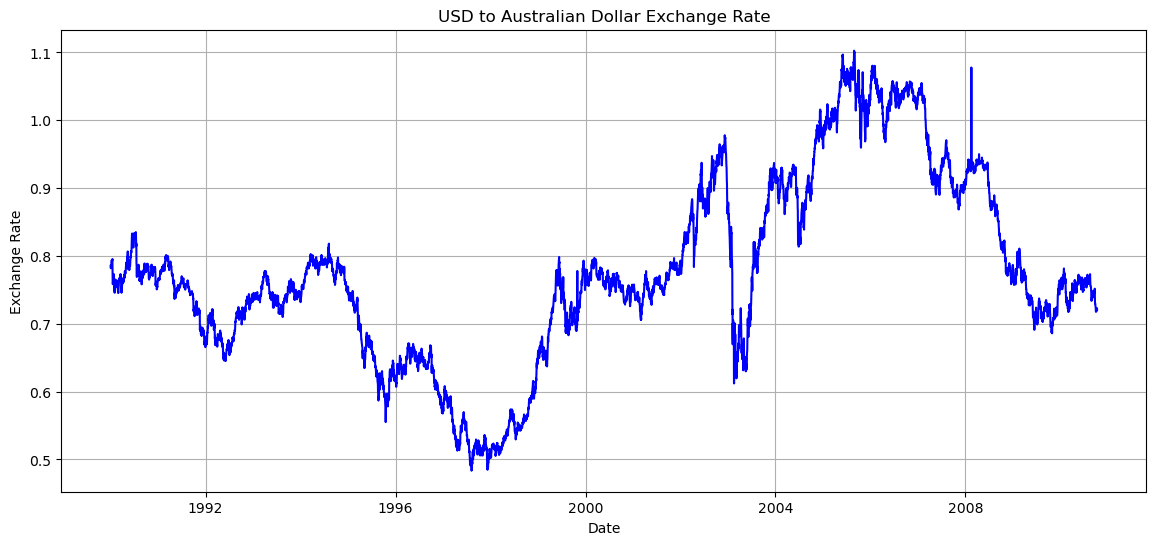

In [4]:
# =========================
# 4. TIME SERIES VISUALIZATION
# =========================

plt.figure(figsize=(14,6))

plt.plot(df.index, df['Ex_rate'], color='blue')

plt.title("USD to Australian Dollar Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.grid(True)
plt.show()


In [5]:
# =========================
# 5. CHECK STATIONARITY
# =========================

result = adfuller(df['Ex_rate'])

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

if result[1] < 0.05:
    print("The series is stationary")
else:
    print("The series is non-stationary")


ADF Statistic : -1.6649941807380735
p-value       : 0.4492327353598314
The series is non-stationary


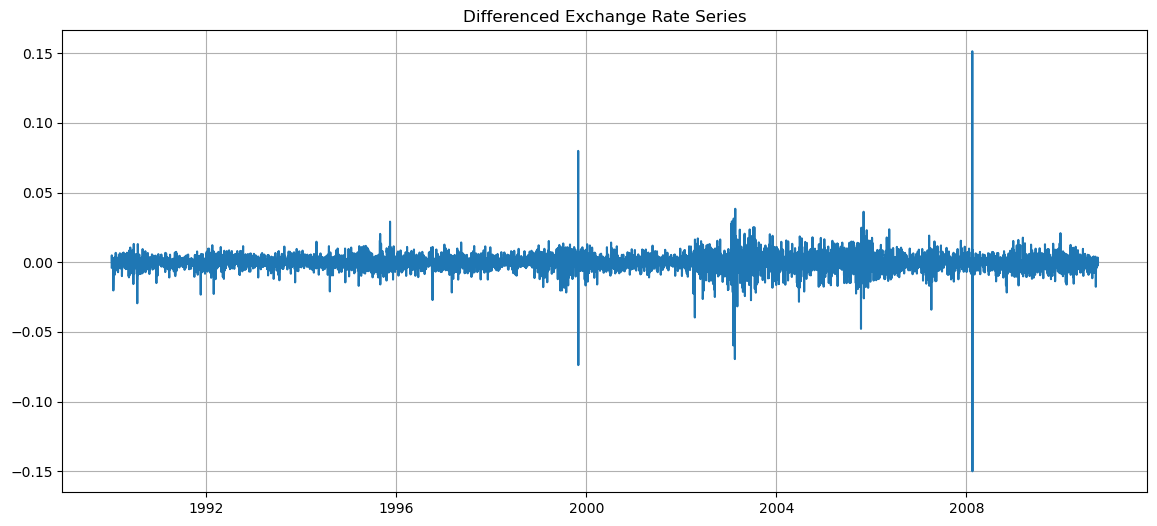

In [6]:
# =========================
# 6. DIFFERENCING
# =========================

df_diff = df['Ex_rate'].diff().dropna()

plt.figure(figsize=(14,6))

plt.plot(df_diff)

plt.title("Differenced Exchange Rate Series")
plt.grid(True)

plt.show()

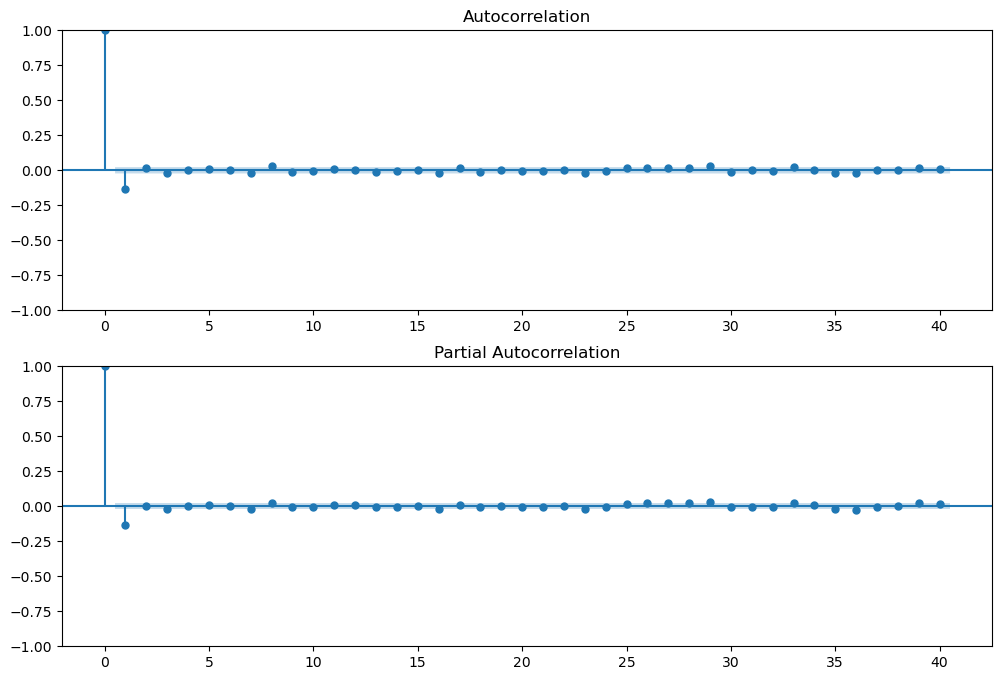

In [7]:
# =========================
# 7. ACF AND PACF PLOTS
# =========================

fig, ax = plt.subplots(2,1, figsize=(12,8))

plot_acf(df_diff, lags=40, ax=ax[0])
plot_pacf(df_diff, lags=40, ax=ax[1])

plt.show()

In [8]:
# ============================================================
# PART 2 : MODEL BUILDING
# ============================================================

# =========================
# 8. TRAIN TEST SPLIT
# =========================

train_size = int(len(df) * 0.80)

train = df['Ex_rate'][:train_size]
test = df['Ex_rate'][train_size:]

print("Training Size :", len(train))
print("Testing Size  :", len(test))


Training Size : 6070
Testing Size  : 1518


In [9]:
# =========================
# 9. BUILD ARIMA MODEL
# =========================

# ARIMA(p,d,q)
# Selected:
# p = 1
# d = 1
# q = 1

arima_model = ARIMA(train, order=(1,1,1))

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Fri, 15 May 2026   AIC                         -45432.092
Time:                        11:57:52   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

In [10]:
# =========================
# 10. ARIMA FORECASTING
# =========================

arima_forecast = arima_fit.forecast(steps=len(test))

# Convert forecast into series
arima_forecast = pd.Series(arima_forecast, index=test.index)

print(arima_forecast.head())


date
2006-08-15    1.023685
2006-08-16    1.023606
2006-08-17    1.023653
2006-08-18    1.023625
2006-08-19    1.023642
Name: predicted_mean, dtype: float64


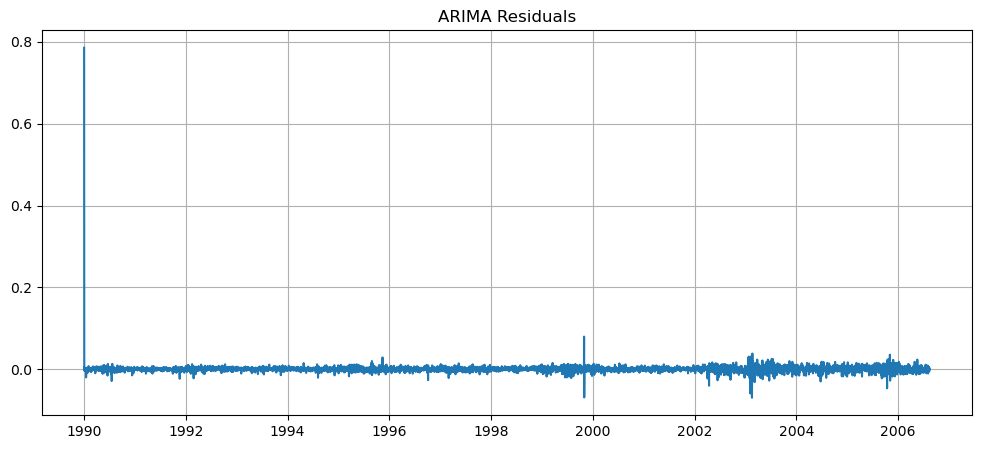

In [11]:

# =========================
# 11. ARIMA RESIDUAL ANALYSIS
# =========================

residuals = arima_fit.resid

plt.figure(figsize=(12,5))

plt.plot(residuals)

plt.title("ARIMA Residuals")
plt.grid(True)

plt.show()

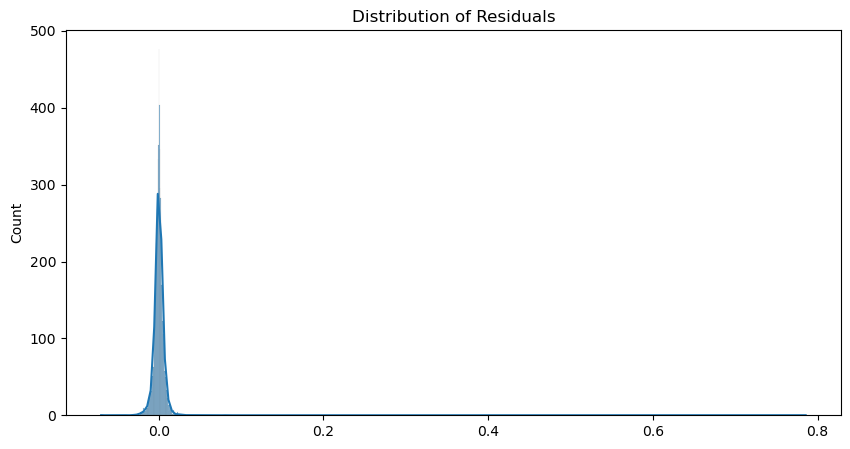

In [13]:
import seaborn as sns
# Histogram of residuals
plt.figure(figsize=(10,5))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")

plt.show()

In [14]:
# ============================================================
# EXPONENTIAL SMOOTHING MODEL
# ============================================================

# =========================
# 12. BUILD EXPONENTIAL SMOOTHING MODEL
# =========================

exp_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)

exp_fit = exp_model.fit()

In [15]:
# =========================
# 13. EXPONENTIAL SMOOTHING FORECAST
# =========================

exp_forecast = exp_fit.forecast(len(test))

exp_forecast = pd.Series(exp_forecast, index=test.index)

print(exp_forecast.head())

date
2006-08-15    1.023559
2006-08-16    1.023577
2006-08-17    1.023594
2006-08-18    1.023611
2006-08-19    1.023628
dtype: float64


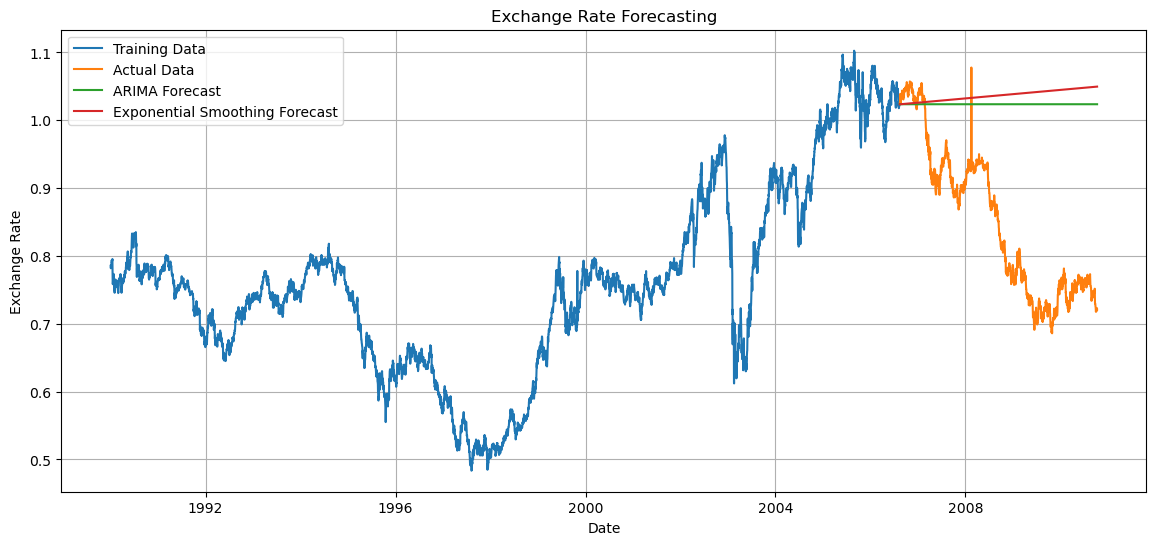

In [16]:
# ============================================================
# 14. VISUALIZE FORECASTS
# ============================================================

plt.figure(figsize=(14,6))

plt.plot(train.index, train, label='Training Data')

plt.plot(test.index, test, label='Actual Data')

plt.plot(arima_forecast.index,
         arima_forecast,
         label='ARIMA Forecast')

plt.plot(exp_forecast.index,
         exp_forecast,
         label='Exponential Smoothing Forecast')

plt.title("Exchange Rate Forecasting")

plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid(True)

plt.show()

In [17]:
# ============================================================
# PART 3 : MODEL EVALUATION
# ============================================================

# =========================
# 15. EVALUATION METRICS
# =========================

def calculate_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100


# ---------- ARIMA METRICS ----------

arima_mae = mean_absolute_error(test, arima_forecast)

arima_rmse = np.sqrt(
    mean_squared_error(test, arima_forecast)
)

arima_mape = calculate_mape(test, arima_forecast)

In [18]:
# ---------- EXPONENTIAL SMOOTHING METRICS ----------

exp_mae = mean_absolute_error(test, exp_forecast)

exp_rmse = np.sqrt(
    mean_squared_error(test, exp_forecast)
)

exp_mape = calculate_mape(test, exp_forecast)


In [19]:
# =========================
# 16. DISPLAY RESULTS
# =========================

results = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE': [arima_mae, exp_mae],
    'RMSE': [arima_rmse, exp_rmse],
    'MAPE': [arima_mape, exp_mape]
})

print("\nMODEL PERFORMANCE COMPARISON\n")

print(results)


MODEL PERFORMANCE COMPARISON

                   Model      MAE      RMSE       MAPE
0                  ARIMA  0.17771  0.205437  22.797966
1  Exponential Smoothing  0.19028  0.220093  24.413565


In [20]:
# ============================================================
# 17. CONCLUSION
# ============================================================

best_model = results.loc[results['RMSE'].idxmin(), 'Model']

print("\nBest Performing Model :", best_model)

print("""
Conclusion:
-----------
1. ARIMA captures autocorrelation patterns effectively.
2. Exponential Smoothing performs well for trend data.
3. The model with lower MAE, RMSE, and MAPE is considered better.
4. Based on RMSE, the best forecasting model is selected.
""")


Best Performing Model : ARIMA

Conclusion:
-----------
1. ARIMA captures autocorrelation patterns effectively.
2. Exponential Smoothing performs well for trend data.
3. The model with lower MAE, RMSE, and MAPE is considered better.
4. Based on RMSE, the best forecasting model is selected.

